# DSC 630 Term Project for Rachel Wantuch
## Wildfire Prediction
### Data Source: https://zenodo.org/records/14712845

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# EDA
## Looking at the Strcuture of the Data

In [177]:
df=pd.read_csv("CA_Weather_Fire_Dataset_1984-2025.csv")
df.head()

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
0,1984-01-01,0.0,79.0,51.0,4.70,False,1984,28.0,0.059494,1,Winter,0.0,4.700,1
1,1984-01-02,0.0,71.0,46.0,5.59,False,1984,25.0,0.078732,1,Winter,0.0,5.145,2
2,1984-01-03,0.0,70.0,47.0,5.37,False,1984,23.0,0.076714,1,Winter,0.0,5.220,3
3,1984-01-04,0.0,76.0,45.0,4.70,False,1984,31.0,0.061842,1,Winter,0.0,5.090,4
4,1984-01-05,0.0,74.0,49.0,5.14,False,1984,25.0,0.069459,1,Winter,0.0,5.100,5


In [137]:
df.shape

(14988, 14)

### Missing Vlaues

In [138]:
df.isnull().sum()

DATE                      0
PRECIPITATION             1
MAX_TEMP                  1
MIN_TEMP                  1
AVG_WIND_SPEED           12
FIRE_START_DAY            0
YEAR                      0
TEMP_RANGE                1
WIND_TEMP_RATIO          12
MONTH                     0
SEASON                    0
LAGGED_PRECIPITATION      0
LAGGED_AVG_WIND_SPEED     0
DAY_OF_YEAR               0
dtype: int64

There is a very small number of missing values in a few of the columns. Average wind speed and wind temp ratio come in with the two highest missing values. This makes sense as wind temp ratio uses average wind speed to calculate itself. Since the number of missing values max's out at 12 I want to see what those rows look like.

In [139]:
df[df.isnull().any(axis=1)]

,DATE,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,FIRE_START_DAY,YEAR,TEMP_RANGE,WIND_TEMP_RATIO,MONTH,SEASON,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
4808,1997-03-01,0.0,64.0,46.0,NaN,False,1997,18.0,NaN,3,Spring,0.00,12.788333,60
4809,1997-03-02,0.0,60.0,45.0,NaN,False,1997,15.0,NaN,3,Spring,0.00,13.556000,61
4810,1997-03-03,0.0,59.0,47.0,NaN,False,1997,12.0,NaN,3,Spring,0.00,13.925000,62
14879,2024-09-26,0.0,70.0,60.0,NaN,False,2024,10.0,NaN,9,Fall,0.00,7.678333,270
14971,2024-12-27,0.0,61.0,49.0,NaN,False,2024,12.0,NaN,12,Winter,0.01,5.183333,362
14972,2024-12-28,0.0,59.0,53.0,NaN,False,2024,6.0,NaN,12,Winter,0.01,5.102000,363
14973,2024-12-29,0.0,58.0,47.0,NaN,False,2024,11.0,NaN,12,Winter,0.01,5.370000,364
14974,2024-12-30,0.0,62.0,52.0,NaN,False,2024,10.0,NaN,12,Winter,0.01,5.220000,365
14975,2024-12-31,NaN,NaN,NaN,NaN,False,2024,NaN,NaN,12,Winter,0.00,4.920000,366
14976,2025-01-01,0.0,59.0,47.0,NaN,False,2025,12.0,NaN,1,Winter,0.00,4.700000,1


There definitely is one row that seems to be row 14975 that causes most of the issues. To fix the 12 rows I decided to use linear interpolation since its a time series and the things being measured follow either increasing or decreasing trends.

In [140]:
df.interpolate(limit_direction="both",inplace=True)

In [141]:
df.isnull().sum()

DATE                     0
PRECIPITATION            0
MAX_TEMP                 0
MIN_TEMP                 0
AVG_WIND_SPEED           0
FIRE_START_DAY           0
YEAR                     0
TEMP_RANGE               0
WIND_TEMP_RATIO          0
MONTH                    0
SEASON                   0
LAGGED_PRECIPITATION     0
LAGGED_AVG_WIND_SPEED    0
DAY_OF_YEAR              0
dtype: int64

Another way to find out if it worked is to get the info about each column which returns a few extra bits of info too.

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14988 entries, 0 to 14987
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DATE                   14988 non-null  object 
 1   PRECIPITATION          14988 non-null  float64
 2   MAX_TEMP               14988 non-null  float64
 3   MIN_TEMP               14988 non-null  float64
 4   AVG_WIND_SPEED         14988 non-null  float64
 5   FIRE_START_DAY         14988 non-null  bool   
 6   YEAR                   14988 non-null  int64  
 7   TEMP_RANGE             14988 non-null  float64
 8   WIND_TEMP_RATIO        14988 non-null  float64
 9   MONTH                  14988 non-null  int64  
 10  SEASON                 14988 non-null  object 
 11  LAGGED_PRECIPITATION   14988 non-null  float64
 12  LAGGED_AVG_WIND_SPEED  14988 non-null  float64
 13  DAY_OF_YEAR            14988 non-null  int64  
dtypes: bool(1), float64(8), int64(3), object(2)
memory usa

In [174]:
df.describe()

,PRECIPITATION,MAX_TEMP,MIN_TEMP,AVG_WIND_SPEED,YEAR,TEMP_RANGE,LAGGED_PRECIPITATION,LAGGED_AVG_WIND_SPEED,DAY_OF_YEAR
count,14988.000000,14988.000000,14988.000000,14988.000000,14988.000000,14988.000000,14988.000000,14988.000000,14988.000000
mean,0.032313,70.534327,56.493628,7.434026,2004.016813,14.040699,0.226188,7.434198,182.992994
std,0.179538,7.263667,6.767701,2.130924,11.843342,5.995178,0.648705,1.387849,105.523627
min,0.000000,50.000000,33.000000,1.790000,1984.000000,2.000000,0.000000,3.227143,1.000000
25%,0.000000,65.000000,51.000000,6.040000,1994.000000,10.000000,0.000000,6.518571,92.000000
50%,0.000000,70.000000,57.000000,7.160000,2004.000000,12.000000,0.000000,7.478571,183.000000
75%,0.000000,75.000000,62.000000,8.500000,2014.000000,17.000000,0.060000,8.278571,274.000000
max,4.530000,106.000000,77.000000,26.170000,2025.000000,41.000000,8.180000,13.932857,366.000000


### Histograms, Skewness, Kurtosis
#### Histogram- Precipitation
This will show us whether the precipitation follows a normal distribution or not. For Random Forest Classifiers a normal distribution is not a requirement.

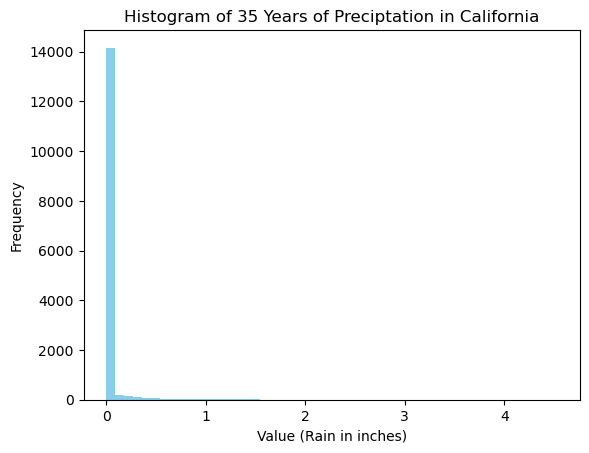

In [143]:
data=df['PRECIPITATION']
plt.hist(data, bins=50, color='skyblue')
plt.title('Histogram of 35 Years of Preciptation in California')
plt.xlabel('Value (Rain in inches)')
plt.ylabel('Frequency')
plt.show()

In [145]:
df['PRECIPITATION'].skew()

np.float64(9.098115180098318)

This distribution is to be expected as far as California's climate goes. We don't get a lot of rain on a regular basis but there are a few years where El Nino weather patterns bring flood level rain measurements. That is why the chart goes up to almost 5 inches. What may seem like an anomoly is totally feasible given the right weather system and geographic location (i.e. foothills).

### Pie Chart
#### Fire Start Days by Season

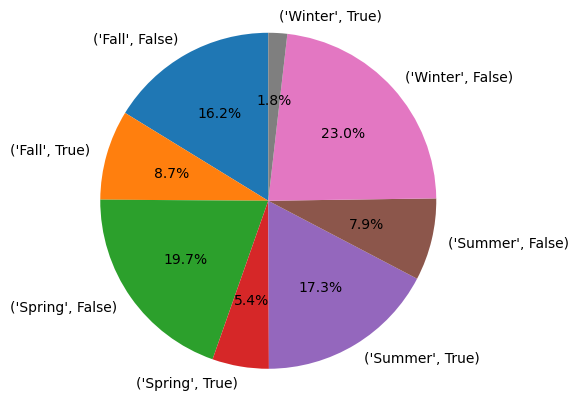

In [146]:
fire_start=df.groupby('SEASON')['FIRE_START_DAY'].value_counts()
plt.pie(fire_start,labels=fire_start.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

The pie chart revealed an unexpected surprise. Growing up in Southern California we view the late fall as fire season because of Santa Ana winds. With this data set though it's showing summer as the leading season for fires starting. This could be based on where they gathered the data or maybe the data was aggregated for the whole state so Northern California affected it more than I am used to.

### Heatmap for Correlation

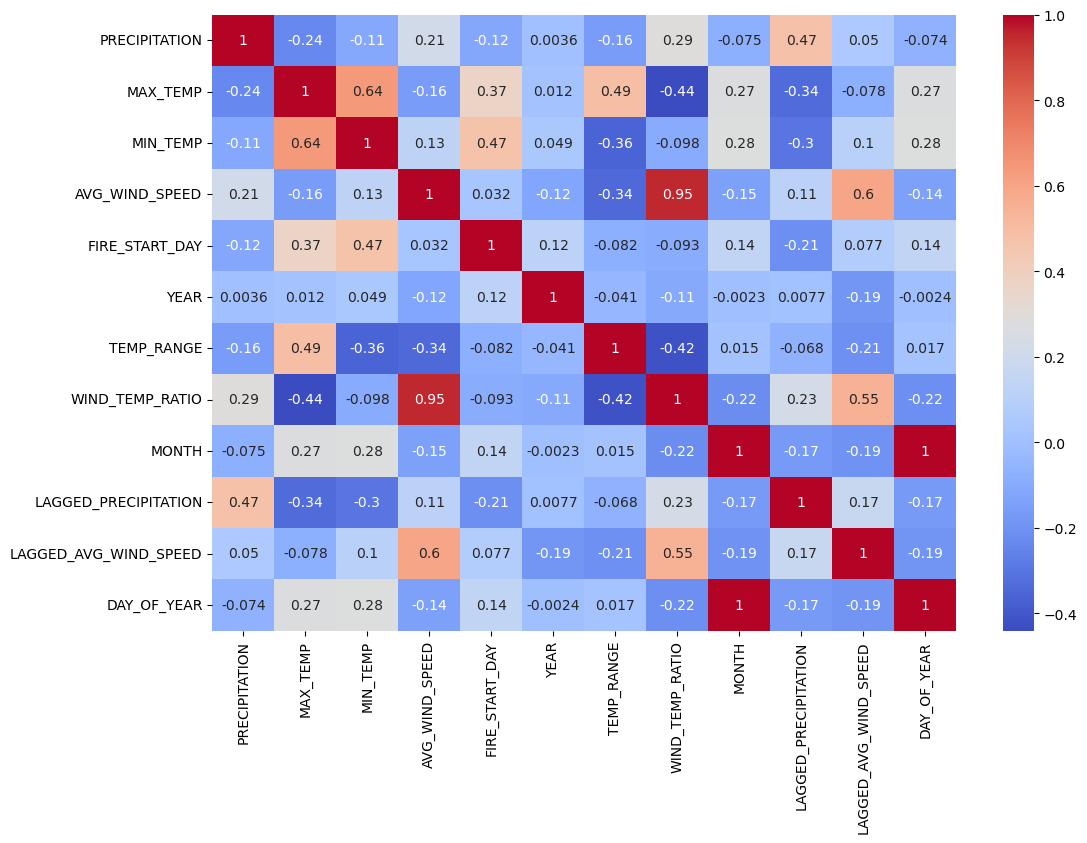

In [147]:
df_nodate=df.drop(['DATE','SEASON'],axis=1)
correlation_matrix=df_nodate.corr()

import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

Above is the correlation heatmap. There are are the usual correlations diagonally through the middle but then there are two highly correlated variables outside of that as well. The first pair is DAY_OF_THE_YEAR/MONTH. This makes sense as the calender starts with Day 1 and based on the number you can get a rough estimate of where it is in the year as far as months go sincemost months have 30 days. Even though RandomForest is robust against high correlations I plan to remove one of those variables to keep my model cleaner.

The other pair of variables that is highly correlated is WIND_TEMP_RATIO/AVG_WIND_SPEED. This one also has some logic to it is AVG_WIND_SPEED is used to calculate the WIND_TEMP_RATIO. I'll be keeping both of these variables as they tell different types of info.

### Dropping Month and Wind Temp Ratio

In [149]:
columns_drop=['MONTH', 'WIND_TEMP_RATIO']
df=df.drop(columns=columns_drop)

### Line Chart
#### Precipitation vs Max Temp by Yearly Average
I chose yearly average for the next two line charts to keep the visual clean and readable.

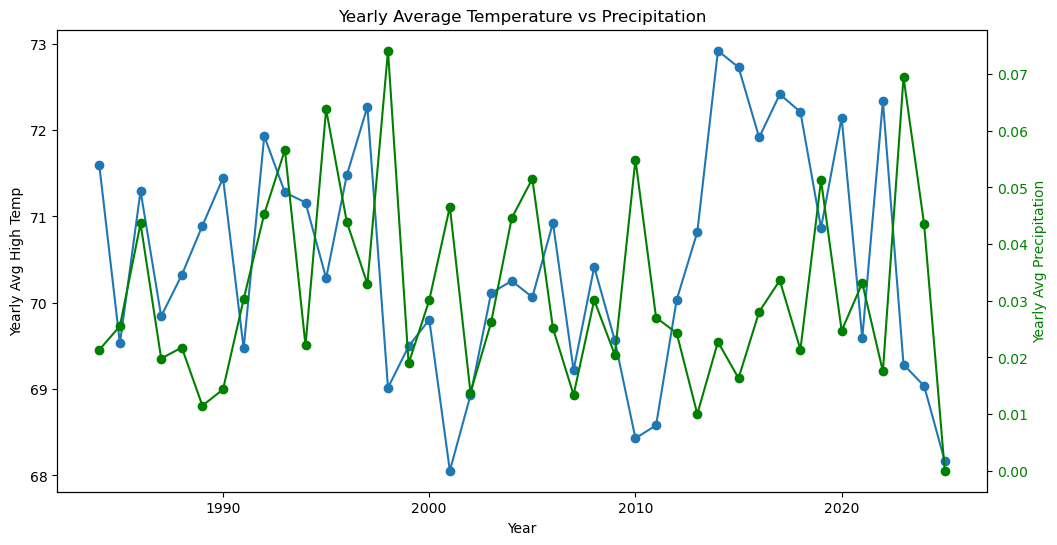

In [150]:
avg_temp_year=df.groupby('YEAR')['MAX_TEMP'].mean().reset_index()
avg_prec_year=df.groupby('YEAR')['PRECIPITATION'].mean().reset_index()

#Creating a Dual Axis Plot
#First Line Plot
fig, ax1=plt.subplots(figsize=(12,6))
ax1.plot(avg_temp_year['YEAR'],avg_temp_year['MAX_TEMP'], marker='o', linestyle='-')
ax1.set_xlabel('Year')
ax1.set_ylabel('Yearly Avg High Temp')
#ax1.xticks(avg_temp_year['YEAR'],rotation=45)

#Creating 2nd axis for precipitation
ax2=ax1.twinx()
ax2.plot(avg_prec_year['YEAR'],avg_prec_year['PRECIPITATION'], color='green', marker='o', linestyle='-')
ax2.set_ylabel('Yearly Avg Precipitation', color='green')
ax2.tick_params(axis='y',labelcolor='green')

plt.title('Yearly Average Temperature vs Precipitation')
plt.show()

## Checking to See If Target Variable is Imbalanced

In [151]:
class_count=df['FIRE_START_DAY'].value_counts()
print("Class counts: \n",class_count)

Class counts: 
 FIRE_START_DAY
False    10017
True      4971
Name: count, dtype: int64


There are many more in the 'False' class for the FIRE_START_DAY so I will need to give more weight to the 'True' class in my model to even things out a bit.

### Hot Encoding of Cateogrical Variables
We only have one cateogrical variable and it is for seasons.

In [152]:
df_encoded=pd.get_dummies(df, columns=['SEASON'],drop_first=True)

# The Models
Note: RandomForest Models does not require feature scaling.
## Model 1 - RandomForest w/ Balanced Classes

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [154]:
df_nodate=df_encoded.drop('DATE',axis=1)

In [155]:
x=df_nodate.drop('FIRE_START_DAY',axis=1)
y=df_nodate['FIRE_START_DAY']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [156]:
rf_class=RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_class.fit(x_train,y_train)
y_pred=rf_class.predict(x_test)

In [157]:
accuracy=accuracy_score(y_test, y_pred)
print(f"The accuracy for this model was: {accuracy * 100:.2f}%")

The accuracy for this model was: 77.92%


By setting the class_weight parameter to balanced the model improved by less than 1% showing that RandomForest by its nature handles imbalanced classes pretty well.

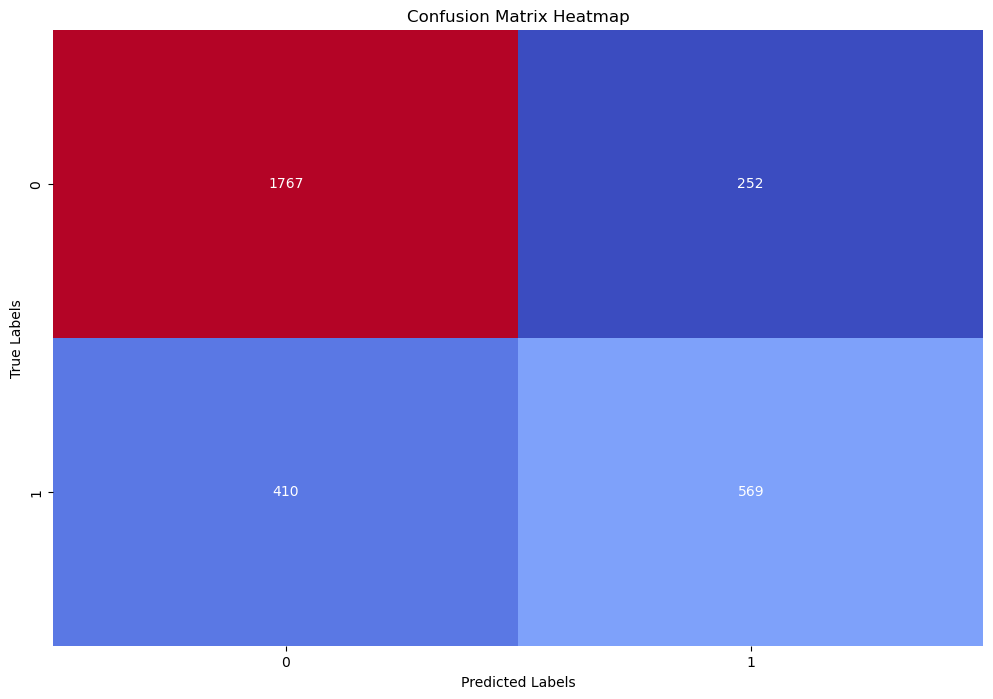

In [158]:
c_matrix2=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(c_matrix2, annot=True, fmt='g',cmap='coolwarm', cbar=False)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

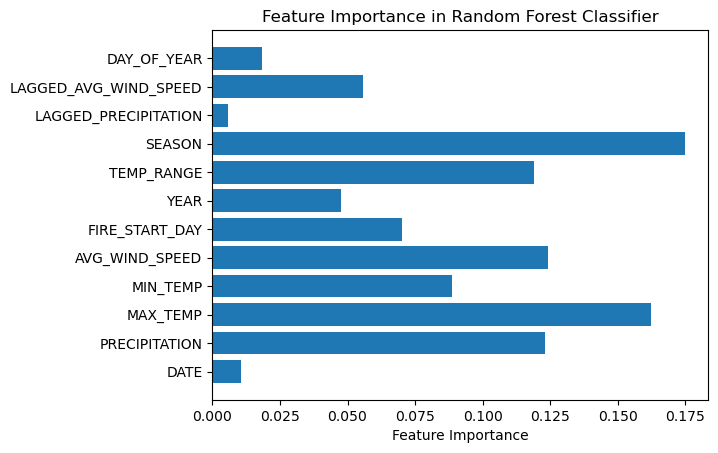

In [159]:
feature_importances=rf_class.feature_importances_
plt.barh(df.columns,feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest Classifier")
plt.show()

In [160]:
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

### Classification Report

In [161]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.81      0.88      0.84      2019
        True       0.69      0.58      0.63       979

    accuracy                           0.78      2998
   macro avg       0.75      0.73      0.74      2998
weighted avg       0.77      0.78      0.77      2998



All metrics improved by approx 1% when setting classs_weight to balanced.

## ROC AUC

In [162]:
y_pred_prob=rf_class.predict_proba(x_test)[:,1]

In [163]:
from sklearn.metrics import roc_auc_score

In [164]:
roc_auc=roc_auc_score(y_test,y_pred_prob)
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8445804186074986


In [165]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob,pos_label=1)

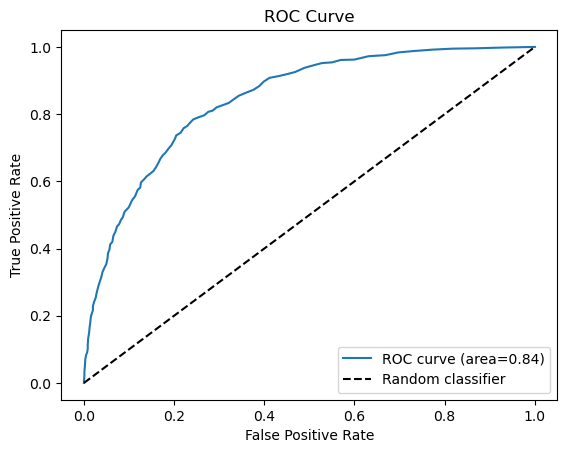

In [166]:
plt.plot(fpr,tpr,label="ROC curve (area=%0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--',label="Random classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= "lower right")
plt.show()

THe ROC AUC curve is showing that this modle is generally pretty good. A really good model would have the a TPR of 1 when the FPR is 0. 

## Model 2 - Random Forest using GridSearchCV

In [167]:
from sklearn.model_selection import GridSearchCV

In [89]:
param_grid={
    'n_estimators':[100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'bootstrap':[True,False]
}

grid_search=GridSearchCV(RandomForestClassifier(),
                         param_grid=param_grid,cv=5)
grid_search.fit(x_train,y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:",grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Estimator: RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200)


One note for the class_weight below. I ran class_weight as 'balanced' and 'balanced_subsample' and they returned the exact same results.

In [168]:
rf_class=RandomForestClassifier(max_depth=10,min_samples_split=5,n_estimators=200, class_weight='balanced',random_state=42)
rf_class.fit(x_train,y_train)
y_pred=rf_class.predict(x_test)

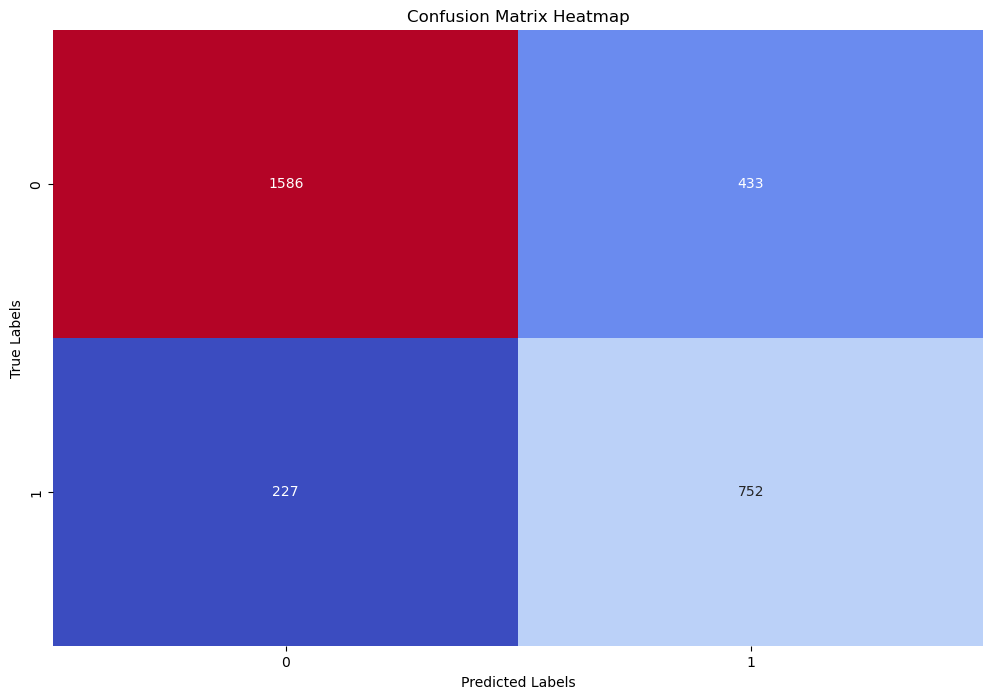

In [169]:
c_matrix2=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(c_matrix2, annot=True, fmt='g',cmap='coolwarm', cbar=False)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [170]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.87      0.79      0.83      2019
        True       0.63      0.77      0.70       979

    accuracy                           0.78      2998
   macro avg       0.75      0.78      0.76      2998
weighted avg       0.80      0.78      0.78      2998



In [171]:
y_pred_prob=rf_class.predict_proba(x_test)[:,1]
roc_auc=roc_auc_score(y_test,y_pred_prob)
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.8545518291248461


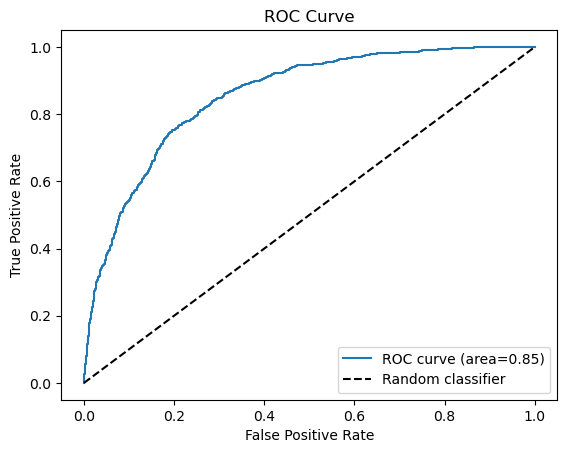

In [172]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob,pos_label=1)

plt.plot(fpr,tpr,label="ROC curve (area=%0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--',label="Random classifier")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc= "lower right")
plt.show()

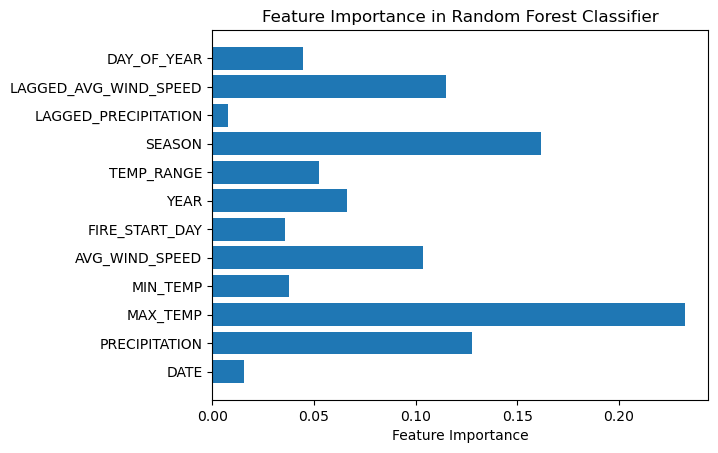

In [173]:
feature_importances=rf_class.feature_importances_
plt.barh(df.columns,feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest Classifier")
plt.show()